<a href="https://colab.research.google.com/github/zinab4/LogisticRegression/blob/main/chatbot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

zinab abd al khalek


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.tokenize import word_tokenize
import nltk
import string

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

import difflib
import random

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
df = pd.read_excel('/content/icthub_dataset.xlsx')
df.head()

,User Input,Category,Chatbot Response
0,Good morning,Greeting,Welcome to ICTHUB - For Digital Solutions! \n\...
1,Good afternoon,Greeting,Welcome to ICTHUB - For Digital Solutions! \n\...
2,Good evening,Greeting,Welcome to ICTHUB - For Digital Solutions! \n...
3,Hi there,Greeting,\n Welcome to ICTHUB - For Digital Solutions!...
4,Hello,Greeting,\n Welcome to ICTHUB - For Digital Solutions!...


In [ ]:
df['Category'].value_counts()

,count
Category,
Asking for Internship Details,82
Thanking Message,69
General_Info_Services,68
AI Internship Details,66
data analysis internship details,64
Web Development internship details,64
Cyber Security Internship Details,64
flutter internship details,64
supply chain internship details,64


In [ ]:
len(df['Category'].value_counts())

11

In [ ]:
df.shape

(715, 3)

In [ ]:
df.isnull().sum()

,0
User Input,0
Category,0
Chatbot Response,0


In [ ]:
df.duplicated().sum()


np.int64(2)

In [ ]:
df.drop_duplicates(inplace=True)

Preprocessing

In [ ]:
def preprocessing(text):

  text = text.lower()

  text = word_tokenize(text)

  # remove special characters
  filtered_text =[]
  for word in text:
    if word.isalnum():
      filtered_text.append(word)

  text = filtered_text[:]
  filtered_text.clear()

  # remove stopwords and punctuation
  for word in text:
    if word not in stopwords.words('english') and word not in string.punctuation:
      filtered_text.append(word)

  text = filtered_text[:]
  filtered_text.clear()

  # stemming
  ps = PorterStemmer()
  for word in text:
    filtered_text.append(ps.stem(word))
  text = filtered_text[:]
  filtered_text.clear()

  return " ".join(text)

In [ ]:
df['Preprocessed'] = df['User Input'].apply(preprocessing)
df.head()

,User Input,Category,Chatbot Response,Preprocessed
0,Good morning,Greeting,Welcome to ICTHUB - For Digital Solutions! \n\...,good morn
1,Good afternoon,Greeting,Welcome to ICTHUB - For Digital Solutions! \n\...,good afternoon
2,Good evening,Greeting,Welcome to ICTHUB - For Digital Solutions! \n...,good even
3,Hi there,Greeting,\n Welcome to ICTHUB - For Digital Solutions!...,hi
4,Hello,Greeting,\n Welcome to ICTHUB - For Digital Solutions!...,hello


In [ ]:
X = df['Preprocessed']
y = df['Category']

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y) # Spam = > 0 , Ham =>1

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

tfid_vec = TfidfVectorizer()
X_train = tfid_vec.fit_transform(X_train)
X_test = tfid_vec.transform(X_test)

In [ ]:
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

In [ ]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("accuracy: ",acc*100)

accuracy:  97.19626168224299


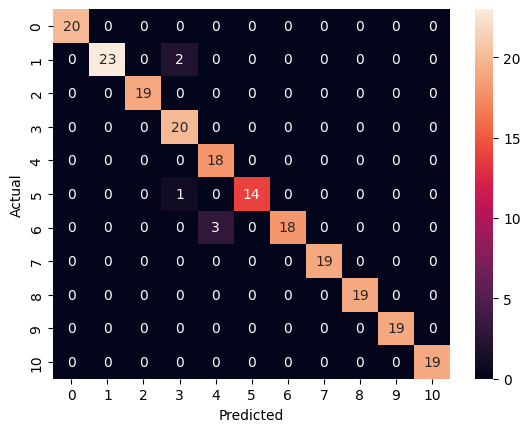

In [ ]:

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

GUI

In [ ]:
# Upgrade Python packages and install/update system packages needed for audio, LaTeX, and PDF generation
!pip install --upgrade gradio gTTS pydub SpeechRecognition ffmpeg-python fpdf && \
apt-get update && \
apt-get -y install --only-upgrade ffmpeg texlive-full latexmk


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 7.8 MB/s eta 0:00:00
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40704 sha256=07c35c8e46d3d4597a9aa8d959526be0e1d97092e61a9a1382a8a8bc5103f864
  Stored in directory: /root/.cache/pip/wheels/65/4f/66/bbda9866da446a72e206d6484cd97381cbc7859a7068541c36
Successfully built fpdf
  Attempting uninstall: click
    Found existing installation: click 8.2.1
    Uninstalling click-8.2.1:
      Successfully uninstalled click-8.2.1
  Attempting uninstall: gradio
    Found existing installation: gradio 5.38.1
    Uninstalling gradio-5.38.1:
      Successfully uninstalled gradio-5.38.1
Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cu

ChatBot


In [ ]:
known_words = list(tfid_vec.vocabulary_.keys())

def is_similar_to_known_words(user_input,min_matches=1) : # True o  Flas
  words = user_input.split()
  match_count =0
  for word in words:
    close =difflib.get_close_matches(word,known_words,n=1,cutoff=0.75)
    if close:
      match_count+=1
    return match_count>=min_matches

In [ ]:
def chatbot(User_Inpt):
  User_Inpt=preprocessing(User_Inpt)

  # check similar
  if not is_similar_to_known_words(User_Inpt):
    return "Chatbot: Sorry, I didn't understand that."

  User_Inpt=tfid_vec.transform([User_Inpt])

  predicted_category = model.predict(User_Inpt)
  predicted_category = label_encoder.inverse_transform(predicted_category)[0]
  # map the answer and and make random answer
  responses = df.groupby('Category')['Chatbot Response'].apply(list).to_dict()
  response = random.choice(responses[predicted_category]).strip()

  if len(response) >0:
    return "Chatbot: " + response
  else:
    return "Chatbot: Sorry, I didn't understand that"

In [ ]:
User_Input = input("you: ")
chatbot(User_Input)


you: hi


"Chatbot: Welcome to ICTHUB - For Digital Solutions! \n\nHello there! I'm your virtual assistant, here to help you navigate through our digital world of innovative solutions. Whether you have questions, need support, or are looking to explore our services, I'm here to make your experience smooth and enjoyable. Let's get started on transforming your digital journey together!\n\nHow can I assist you today?"

In [ ]:
print("Hello! I am your chatbot")
print("type 'exit' to end the caht")
while True:
  User_Inpt = input("You: ")
  if User_Inpt.lower() == 'exit':
    break
  response = chatbot(User_Inpt)
  print(response)

Hello! I am your chatbot
type 'exit' to end the caht
You: exit


In [ ]:
import gradio as gr

with gr.Blocks(theme=gr.themes.Soft(), css="""
body {
    background-color: #748DAE;
}

.gr-chatbot {
    background-color: #ffffff !important;
    color: #000000 !important;
    border-radius: 12px;
    padding: 1rem;
}

#welcome_text {
    text-align: center;
    color: #2A4365;
    font-size: 42px;
    font-weight: bold;
    margin-top: 1rem;
}

#header_row {
    display: flex;
    align-items: center;
    justify-content: center;
    margin-bottom: 1rem;
}

#logo_container {
    display: flex;
    justify-content: center;
    align-items: center;
    margin-bottom: 1rem;
    border-radius: 12px;
}

#logo_image {
    max-width: 100%;
    width: 300px;
}

#chat_wrapper {
    flex: 1;
    display: flex;
    justify-content: center;
    align-items: center;
    padding: 1rem;
}

#chat_column {
    background-color: #748DAE;
    border-radius: 6px;
    padding: 1rem;
    max-width: 1000px;
    width: 100%;
    height: 85vh;
    display: flex;
    flex-direction: column;
    justify-content: space-between;
}

#chatbot_box {
    flex: 1;
    overflow-y: auto;
    margin-bottom: 1rem;
    font-size: 20px;
}

#send_button {
    border-radius: 8px;
    font-size: 20px;
    font-weight: bold;
    background-color: #1F4172 !important;
    color: #9ECAD6 !important;
    border: none;
    padding: 0.6rem 1.2rem;
}
""") as demo:

    # Header
    with gr.Row(elem_id="header_row"):
        with gr.Column():
            with gr.Row(elem_id="logo_container"):
                gr.Image(value="/content/icthub_logo.png", elem_id="logo_image", show_label=False, container=False)
            gr.Markdown("Welcome to ICT Hub", elem_id="welcome_text")

    # Chat section
    with gr.Row(elem_id="chat_wrapper"):
        with gr.Column(elem_id="chat_column"):
            chatbot_ui = gr.Chatbot(label="", elem_id="chatbot_box")
            user_input = gr.Textbox(placeholder="Type your message...", label="Your Message")
            send_btn = gr.Button("Send", elem_id="send_button")

            # Response function
            def respond(message, chat_history):
                bot_response = chatbot(message)
                chat_history.append((message, bot_response))
                return "", chat_history

            send_btn.click(fn=respond, inputs=[user_input, chatbot_ui], outputs=[user_input, chatbot_ui])

demo.launch()

/tmp/ipython-input-202-1602998627.py:91: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chatbot_ui = gr.Chatbot(label="", elem_id="chatbot_box")


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3b5569d4a9fe1961f4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
